## Segmentation

Unlike classifiers, the segmentation aim to understand the content of an image at the pixel level. In the following example, we use the dataset ***Camvid Tiny***, a reduced version of the dataset for the autonomous driving, to teach the model at recognize components like roads, signals and objects.

In [ ]:
from fastai.vision.all import *
    from fastcore.all import *


path = untar_data(URLs.CAMVID_TINY)
dls = SegmentationDataLoaders.from_label_func(
    path, bs = 8, fnames = get_image_files(path/"images"),
    label_func = lambda o: path/'labels'/f'{o.stem}_P{o.suffix}',
    codes = np.loadtxt(path/'codes.txt',dtype = str)
)


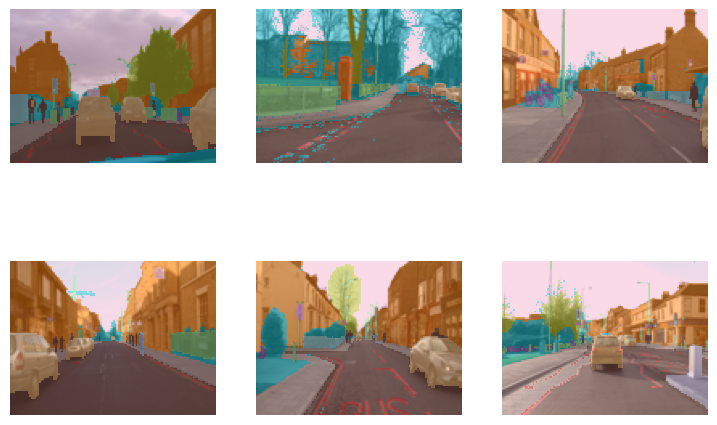

In [26]:
dls.show_batch(max_n=6)

- **SegmentationDataLoaders**: Fastai object specialized on managing pairs of images( the original image and its mask(the image colored with labels))

- **fnames**: Collect all the files from a directory

- **label_func**: This function is a mapping function. For every image file, it tells the computer where to find the "mask"(the ground truth color-coded image). It looks inside the /labels folder and adds a _P suffix to the filename, which is how this specific dataset matches images to their labels.

- **Codes**: We load the file *codex.txt* that works as instructions. This file combines the saved numbers on the pixels of the mask to readable names. Without this, the model would distinguish the areas but it wouldn't know how to name them

In [28]:
learn1 = unet_learner(dls, resnet34)
learn1.fine_tune(8)

epoch,train_loss,valid_loss,time
0,2.889032,2.362635,00:50


epoch,train_loss,valid_loss,time
0,1.898105,1.542094,00:53
1,1.606349,1.351046,00:52
2,1.481595,1.074770,00:52
3,1.341752,0.974678,00:51
4,1.208765,0.811201,00:51
5,1.092034,0.759300,00:52
6,0.994687,0.730879,00:50
7,0.920947,0.735379,00:51


The segmentation required the *unet_learner* function beacause we need to know where each pixel is. If we compresse too much, we'll lose some details of the images.

The **U-Net** architecture solves this problem with an U form:
- ***Encoder(Left Side)***: is a ResNet thath analyze the picture and extract the meaning
- ***Decoder(Right Side)***: it does the opposite of the encoder. Takes the compressed informations and expand them to the original dimension.

U-net uses the skip connections:
While the model try to reconstruct the images from the *Decoder*, it receive hints or direct data from the *Encoder*
This allows the model to combine the deep learning with spatial precision

In [ ]:
learn1.show_results(max_n = 6, figsize= (12,12))

,userId,movieId,rating,rating_pred
0,48.0,16.0,5.0,4.707355
1,34.0,26.0,5.0,4.151722
2,67.0,22.0,3.5,3.003931
3,10.0,96.0,3.0,3.784816
4,49.0,38.0,5.0,4.509854
5,42.0,49.0,4.5,3.365405


## Tabular analysis

The tabular analysis is the process of training a model on structured data, such as CSV files. Unlike computer vision, where the model looks for patterns in pixels, here the model identifies relationships between **features** (columns) to predict a specific target
(In the following case, the target is *"salary"*)

In [ ]:
from fastai.tabular.all import *
path2 = untar_data(URLs.ADULT_SAMPLE)

dls2 = TabularDataLoaders.from_csv(
    path2/'adult.csv', path2 = path2, y_names = "salary",
    cat_names = ['workclass', 'education','marital-status', 'occupation', 'relationship','race'],
    cont_names = ['age', 'fnlwgt', 'education-num'],
    procs = [Categorify, FillMissing, Normalize])

/home/davidebui/miniforge3/envs/corso_ai/lib/python3.10/site-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)


- **TabularDataLoaders**: The main class to get your data for model training. It allows for the neural network to learn structured data.

- **cat_names**: The names of the categorical variables

- **cont_names**: The names of the continuous variables

- **y_names**: The names of the dependent variables

- **procs**: Defines the operation of pre-elaboration of the data. *Categorify* is used to manage texts, *FillMissing* is used to manage missing data without lose any information, *Normalize* ensures that all numeric variables have the same statistic weight facilitating convergence of the model during the training.

In [14]:
dls2.show_batch()

,workclass,education,marital-status,occupation,relationship,race,education-num_na,age,fnlwgt,education-num,salary
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,False,41.000000,26891.998282,13.0,<50k
1,Local-gov,Some-college,Divorced,Adm-clerical,Unmarried,White,False,46.000000,359192.998642,10.0,<50k
2,?,11th,Never-married,?,Own-child,White,False,17.999999,191116.999970,7.0,<50k
3,Local-gov,HS-grad,Married-civ-spouse,Transport-moving,Husband,White,False,41.000000,176715.999845,9.0,<50k
4,Private,Assoc-voc,Separated,Machine-op-inspct,Not-in-family,Black,False,46.000000,282537.997633,11.0,<50k
5,Private,Bachelors,Married-AF-spouse,Exec-managerial,Wife,White,False,30.000000,169583.000639,13.0,>=50k
6,Private,Some-college,Married-civ-spouse,Protective-serv,Husband,Other,False,43.000000,216696.999518,10.0,<50k
7,Private,Bachelors,Married-civ-spouse,Handlers-cleaners,Husband,White,False,37.000000,324947.003546,13.0,<50k
8,Private,Some-college,Married-civ-spouse,Sales,Husband,White,False,34.000000,302769.997283,10.0,<50k
9,Private,11th,Married-civ-spouse,Adm-clerical,Husband,White,False,58.000000,87328.997430,7.0,<50k


In [ ]:
learn2 = tabular_learner(dls2, metrics = accuracy)
learn2.fit_one_cycle(2)

epoch,train_loss,valid_loss,accuracy,time
0,0.372900,0.369505,0.826628,00:07
1,0.372944,0.354618,0.834613,00:07


We use *fit_one_cycle* because for tabular models, there's not generally going to be a pre-trained model that already does something that you want because every table of data is different.

This method efficiently manages the learning rate to find the optimal solution quickly, adapting to the specific patterns of our unique data table

In [ ]:
learn3.show_results()

## Collaborative filtering

Collaborative filtering is a system thath recommends items to users based on how other users with similar preferences and behavior have interacted with that item. In other words, collaborative filtering algorithms group users based on behavior and use general group characteristics to reccomend items to a target user.

In [17]:
from fastai.collab import *

path3 = untar_data(URLs.ML_SAMPLE)
dls3 = CollabDataLoaders.from_csv(path3/'ratings.csv')

<div><progress max="51790" value="57344"></progress> 110.72% [57344/51790 00:00&lt;00:00]</div>

We use CollabDataLoaders function to manage datasets that relate users and products. The model doesn't need to know the details of the user such as the age; it learns preferences based on past interactions, finding styles throw Embeddings

In [18]:
dls3.show_batch()

,userId,movieId,rating
0,605,2716,3.0
1,596,6377,3.5
2,134,1036,3.5
3,95,253,4.0
4,580,357,3.5
5,387,2028,5.0
6,346,5952,1.0
7,514,1,4.0
8,380,1240,5.0
9,355,356,5.0


In [ ]:
learn3 = collab_learner(dls3, y_range=(0.5,5.5))
learn3.fine_tune(10)

epoch,train_loss,valid_loss,time
0,1.523067,1.388216,00:00


epoch,train_loss,valid_loss,time
0,1.391030,1.335589,00:00
1,1.305614,1.179704,00:00
2,1.061269,0.899741,00:00
3,0.819110,0.730282,00:01
4,0.704712,0.686236,00:01
5,0.672446,0.669857,00:00
6,0.616538,0.665085,00:00
7,0.605642,0.660925,00:00
8,0.601063,0.659700,00:00
9,0.598032,0.659584,00:00


In [ ]:
learn3.show_results()

,userId,movieId,rating,rating_pred
0,73.0,35.0,2.0,3.977104
1,51.0,8.0,4.5,3.716025
2,80.0,47.0,4.0,4.157846
3,7.0,14.0,2.0,4.322259
4,97.0,24.0,4.0,3.567174
5,62.0,41.0,5.0,4.106832
6,20.0,86.0,4.5,3.570744
7,16.0,7.0,4.0,4.358378
8,18.0,65.0,4.5,3.604174
